In [1]:
#Assorted imports
import numpy as np
import pandas as pd
import h5py
import vaex
import pynbody
from pynbody.array import SimArray

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path

from astropy import units as u
from astropy.io import ascii, fits
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord,CartesianRepresentation,match_coordinates_sky

import functions as fn 
import matched_filter_ani as mf

np.random.seed(0)

In [21]:
#Variable definition
box = 'rogue' 
num = 3
D = 2000 
mlim_str = '26p5' 
name = f'{box}_4096_{num}_data_{D}_{mlim_str}'

size_kpc = 40 
pdist = (size_kpc/D) * (180/np.pi) 
year = 10
mlim = '26'
c1='px'
c2='py'
edgelength = 10 
plotdir = f'{box}_4096_{num}' 
bgcatpath = f"/home/otteleno/MAP/matched_filter/mf_data/bgcats/bgr{mlim}g{mlim}_for_mf_{int(edgelength)}deg.fits"

age = '10'
mh = '-2'

In [22]:
#Loads background data
bgcat = Table.read(bgcatpath,format='fits')
c1bg = bgcat['c1']
c2bg = bgcat['c2']

bgtable = Table()
bgtable['c1'] = c1bg
bgtable['c2'] = c2bg
bgtable['gmag'] = bgcat['gmag']
bgtable['Ag'] = bgcat['Ag'] 
bgtable['rmag'] = bgcat['rmag']
bgtable['Ar'] = bgcat['Ar']
bgtable['flag'] = 'bg'
bgtable['age'] = -99

In [1]:
#Generates fibonacci angles to match file names

def fibonacci_angler(n):

    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/(n-1) ###ONLY GOES HALF WAY DOWN
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio

    declination_readable = [round(x*180/np.pi,1) for x in declination_array]
    azimuthal_readable = [round(np.mod(x*180/np.pi, 360),1) for x in  azimuthal_array]

    return declination_readable, azimuthal_readable

In [26]:
# Adds background data to all the rotations and saves it.
# ONLY RUN IF THESE FILES DON'T ALREADY EXIST (running this won't break anything, but is very time-consuming)
for i in range(len(declination_readable)):
            
    #Shortcuts
    d = declination_readable[i] 
    a = azimuthal_readable[i]
             
    dwarfcatpath = f"/home/otteleno/MAP/matched_filter/mf_data/rotated_catalogs/{box}_{num}/{box}_{num}_d={d}_a={a}.h5"
    save_path = f"/home/otteleno/MAP/matched_filter/mf_data/bg_added_catalogs/{box}_{num}/bg_{box}_{num}_d={d}_a={a}.fits"

    #Adds dwarf data to background data. Saves
    dwarf_table = fn.bg_dwarf_combo(pdist,name,year,D,c1,c2,plotdir,dwarfcatpath,bgcatpath,edgelength,plot=False,save=True,my_save_path = save_path) 
    table_final = vstack([dwarf_table,bgtable])
    table_final.write(save_path,format='fits',overwrite=True)



In [9]:
#More variable defition
rmaglim = 26
numpix = 8000
iso_info = 'parsec'
pix = (np.round(np.sqrt((2*pdist*60)**2 / numpix),2))
catalog = f'/home/otteleno/MAP/matched_filter/mf_data/bgcats/bgr26g26_for_mf_10deg.fits'
field = name+f'_mfmag{rmaglim}_{iso_info}{age}{mh}{c1}{c2}_{np.round(pdist*60,0)}'
signal_file = f"/home/otteleno/MAP/matched_filter/mf_data/signals/{iso_info}_{D}_{age}{mh}_signal_cmd_gr.txt"

Total number of signal CMD
1.0


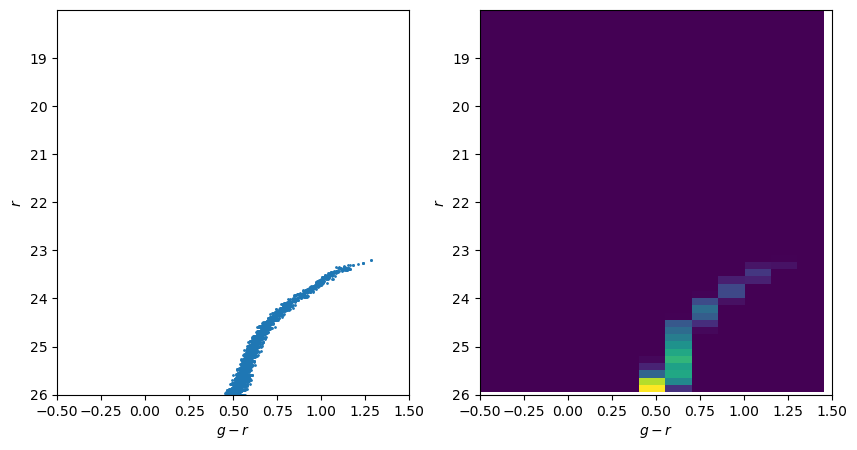

Total number of stars in background CMD
412.4963348323474


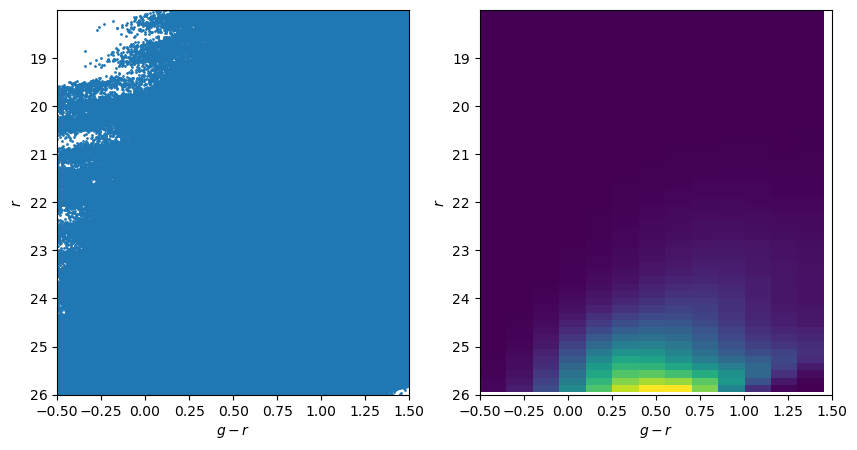

In [10]:
#Creates CMDs
objcmd = mf.mk_norm_objcmd_gd(field, signal_file, rmaglim=rmaglim, plot=True)   
backcmd = mf.mk_norm_backcmd(field, catalog, rmaglim=rmaglim, plot=True, pix=pix)

In [2]:
#Allows for manual selection of unrun angles. Get rid of index splicing if you want all angles.
declination_readable, azimuthal_readable = fibonacci_angler(24)
print(declination_readable, '\n', azimuthal_readable, '\n')
dec=declination_readable[4:]
azi=azimuthal_readable[4:]
print(dec, '\n', azi, '\n')

NameError: name 'np' is not defined

x min  -68.75493541569878
x max  68.75493541569878
y min  -68.75493541569878
y max  68.75493541569878


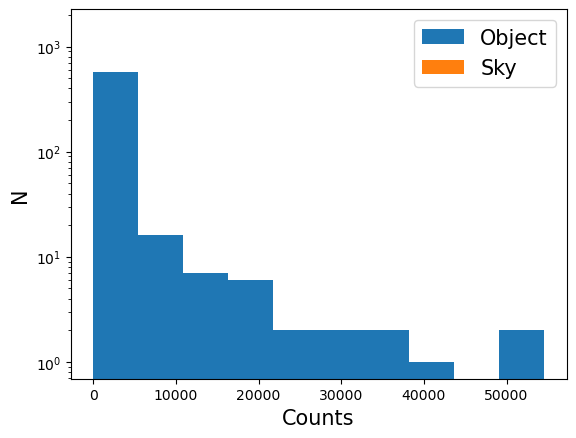

Sigma in smoothed stellar counts 3.474211544593981
Mean in smoothed stellar counts 0.5933001410805463


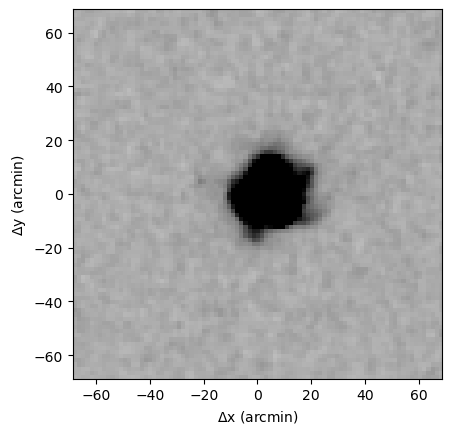

x min  -68.75493541569878
x max  68.75493541569878
y min  -68.75493541569878
y max  68.75493541569878


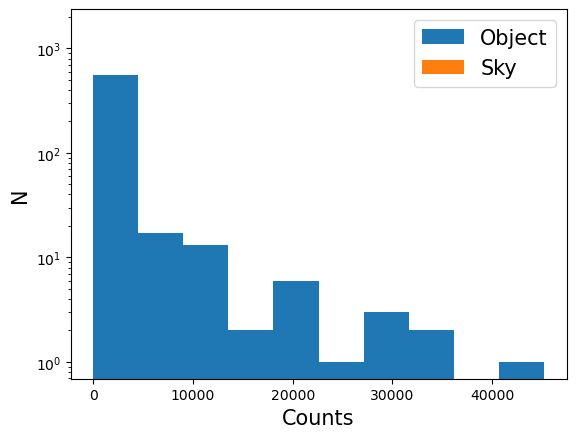

Sigma in smoothed stellar counts 3.5548851310292218
Mean in smoothed stellar counts 0.6413779385778987


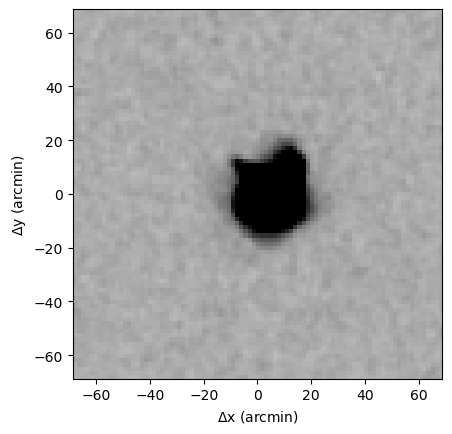

x min  -68.75493541569878
x max  68.75493541569878
y min  -68.75493541569878
y max  68.75493541569878


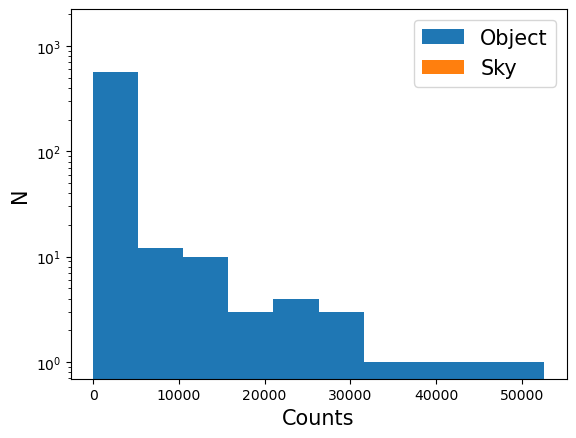

Sigma in smoothed stellar counts 3.5473892192878997
Mean in smoothed stellar counts 0.6531986396653131


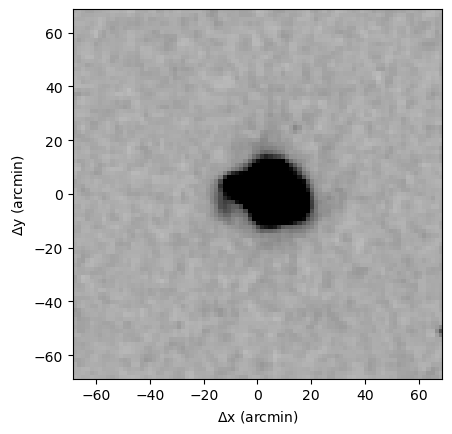

x min  -68.75493541569878
x max  68.75493541569878
y min  -68.75493541569878
y max  68.75493541569878


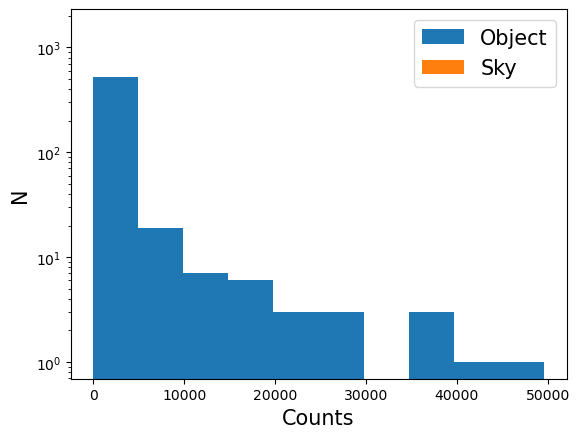

Sigma in smoothed stellar counts 3.544221304022609
Mean in smoothed stellar counts 0.6181499208835405


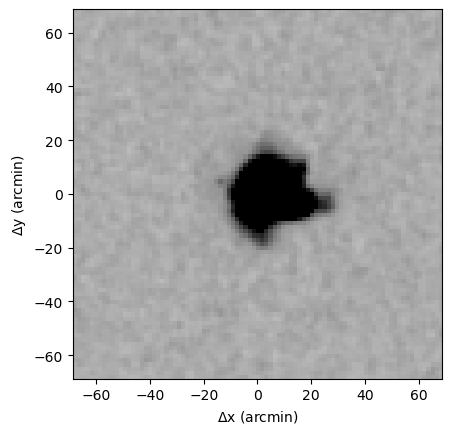

x min  -68.75493541569878
x max  68.75493541569878
y min  -68.75493541569878
y max  68.75493541569878


In [ ]:
#MFA
for i in range(len(declination_readable)):
            
    #Shortcuts
    d = dec[i] 
    a = azi[i]

    #From Background added catalogs to matched filter catalogs
    save_path = f"/home/otteleno/MAP/matched_filter/mf_data/bg_added_catalogs/{box}_{num}/bg_{box}_{num}_d={d}_a={a}.fits"
    second_save_path = f"/home/otteleno/MAP/matched_filter/mf_data/mf_catalogs/{box}_{num}/mf_{box}_{num}_d={d}_a={a}_pix={numpix}.fits"

    #Runs matched filter analysis
    mf.matched_filter_ani(objcmd, backcmd, second_save_path,
        field=field, 
        catalog=save_path,
        plot=True, rmaglim = rmaglim, pix=pix, pdist=pdist*60)